# Replication - comparing sources (selected sources and markets)

## 0. Configuration

In [6]:
# ============================================================
# CELL 0 — Configuration
# This is the only cell you need to edit to change models, paths, or experiment settings.
# ============================================================

import os, sys

# ── Number of questions to evaluate ─────────────────────────
NUM_QUESTIONS = 6

# ── Models ──────────────────────────────────────────────────
# All LLM calls go through this model unless overridden below.
DEFAULT_MODEL = "llama-3.3-70b-versatile"

SEARCH_QUERY_MODEL    = DEFAULT_MODEL
RANKING_MODEL         = DEFAULT_MODEL
SUMMARIZATION_MODEL   = DEFAULT_MODEL
REASONING_MODEL       = DEFAULT_MODEL

# ── LLM Backend ─────────────────────────────────────────────
USE_LOCAL_LLM = True   # Set to False to use Groq instead

# ── Temperatures ────────────────────────────────────────────
SEARCH_QUERY_TEMPERATURE  = 0.0
RANKING_TEMPERATURE       = 0.0
SUMMARIZATION_TEMPERATURE = 0.2
REASONING_TEMPERATURE     = 1.0

# ── Retrieval settings ───────────────────────────────────────
RETRIEVAL_DAYS_BEFORE_RESOLUTION = 10 
NUM_ARTICLES_PER_QUERY = 100   # max articles to fetch per query
RELEVANCE_THRESHOLD    = 4    # 1-6 scale; keep articles rated >= this
TOP_K_ARTICLES         = 15   # keep top K after ranking
MAX_WORDS              = 7
NUM_KEYWORDS           = 10 # total queries per question

TRACKED_SOURCES = [
    "The Guardian",
    "CNN",
    "NBC News",
    "ABC News - Breaking News, Latest News and Videos",
    "Fortune",
    "Al Jazeera",
    "CNBC",
    "Reuters"
]

# ── Paths ────────────────────────────────────────────────────
REPO_ROOT    = os.path.abspath("../../llm_forecasting")  
DATA_PATH    = "markets_data/data.json"               
OUTPUT_DIR   = "results_04"

QUERIES_FILE     = os.path.join(OUTPUT_DIR, "queries.json")
ARTICLES_FILE    = os.path.join(OUTPUT_DIR, "articles.json")
SUMMARIES_FILE   = os.path.join(OUTPUT_DIR, "summaries.json")
PREDICTIONS_FILE = os.path.join(OUTPUT_DIR, "predictions.json")

LOCAL_MODEL_PATH_14B = "/SWS/llms/nobackup/hub/models--Qwen--Qwen2.5-14B-Instruct/snapshots/cf98f3b3bbb457ad9e2bb7baf9a0125b6b88caa8"
LOCAL_MODEL_PATH_7B = "/SWS/llms/nobackup/hub/models--Qwen--Qwen2.5-7B-Instruct/snapshots/a09a35458c702b33eeacc393d103063234e8bc28"

os.makedirs(OUTPUT_DIR, exist_ok=True)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Config OK")
print(f"  Model:      {DEFAULT_MODEL}")
print(f"  Questions:  {NUM_QUESTIONS}")
print(f"  Data:       {DATA_PATH}")
print(f"  Output dir: {OUTPUT_DIR}")

Config OK
  Model:      llama-3.3-70b-versatile
  Questions:  6
  Data:       markets_data/data.json
  Output dir: results_04


## 1. Imports and helpers

In [7]:
import json
import math
import time
import asyncio
import logging
import os
import sys
import torch
from datetime import datetime, timedelta
from transformers import pipeline as hf_pipeline

import numpy as np
import requests
from bs4 import BeautifulSoup
from gnews import GNews
from googlenewsdecoder import gnewsdecoder

# ── Groq client (via openai-compatible API) ──────────────────
import openai
from config.keys import (
    GROQ_API_KEY_1,
    GROQ_API_KEY_2,
    GROQ_API_KEY_3,
    GROQ_API_KEY_4,
    GROQ_API_KEY_5,
)

GROQ_API_KEYS = [
    GROQ_API_KEY_1,
    GROQ_API_KEY_2,
    GROQ_API_KEY_3,
    GROQ_API_KEY_4,
    GROQ_API_KEY_5,
]

groq_clients = [
    openai.OpenAI(
        api_key=key,
        base_url="https://api.groq.com/openai/v1",
    )
    for key in GROQ_API_KEYS
]

exhausted_keys = set()
current_client_idx = 0

# ── Local LLM setup ──────────────────────────────────────────
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

LOCAL_MODEL_PATH = LOCAL_MODEL_PATH_14B
local_pipe = None  # loaded lazily on first call

def _get_local_pipe():
    global local_pipe
    if local_pipe is None:
        print("Loading local model (first call only, takes ~2 min)...")
        local_pipe = hf_pipeline(
            "text-generation",
            model=LOCAL_MODEL_PATH,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )
        print("Local model ready.")
    return local_pipe

# ── Logging ──────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ── Groq LLM call ────────────────────────────────────────────
def call_llm_groq(prompt, model=None, temperature=0.0, max_tokens=4096):
    global current_client_idx, exhausted_keys
    model = model or DEFAULT_MODEL
    while True:
        if len(exhausted_keys) == len(groq_clients):
            raise RuntimeError("All Groq API keys are exhausted.")
        if current_client_idx in exhausted_keys:
            current_client_idx = (current_client_idx + 1) % len(groq_clients)
            continue
        client = groq_clients[current_client_idx]
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return response.choices[0].message.content
        except Exception as e:
            err = str(e).lower()
            quota_error = any(x in err for x in [
                "quota", "credit", "exceeded", "rate limit",
                "insufficient", "billing", "429",
            ])
            if quota_error:
                logger.warning(f"API key #{current_client_idx + 1} exhausted. Switching to next key.")
                exhausted_keys.add(current_client_idx)
                current_client_idx = (current_client_idx + 1) % len(groq_clients)
                continue
            logger.warning(f"LLM call failed with key #{current_client_idx + 1}: {e}. Retrying in 10s...")
            time.sleep(10)

# ── Local LLM call ───────────────────────────────────────────
def call_llm_local(prompt, model=None, temperature=0.0, max_tokens=4096):
    pipe = _get_local_pipe()
    # temperature=0 means greedy decoding
    do_sample = temperature > 0
    messages = [{"role": "user", "content": prompt}]
    out = pipe(
        messages,
        max_new_tokens=max_tokens,
        temperature=temperature if do_sample else None,
        do_sample=do_sample,
    )
    return out[0]["generated_text"][-1]["content"]

def call_llm_local_batch(prompts_list, temperature=0.0, max_tokens=4096):
    """Process a list of prompts in one GPU batch. Returns a list of responses."""
    pipe = _get_local_pipe()
    do_sample = temperature > 0
    messages_list = [[{"role": "user", "content": p}] for p in prompts_list]
    outputs = pipe(
        messages_list,
        max_new_tokens=max_tokens,
        temperature=temperature if do_sample else None,
        do_sample=do_sample,
        batch_size=8,  # process 8 at a time
    )
    return [out[0]["generated_text"][-1]["content"] for out in outputs]

# ── Unified call_llm — respects USE_LOCAL_LLM flag ───────────
def call_llm(prompt, model=None, temperature=0.0, max_tokens=4096):
    if USE_LOCAL_LLM:
        return call_llm_local(prompt, model=model, temperature=temperature, max_tokens=max_tokens)
    else:
        return call_llm_groq(prompt, model=model, temperature=temperature, max_tokens=max_tokens)

# ── JSON file helpers ─────────────────────────────────────────
def load_json(path):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return []

def save_json(path, data):
    with open(path, "w") as f:
        json.dump(data, f, indent=2, default=str)

# ── Date helpers ─────────────────────────────────────────────
def get_single_retrieval_date(date_begin, date_close, date_resolve, community_predictions):
    date_begin_obj   = datetime.strptime(date_begin, "%Y-%m-%d")
    date_close_obj   = datetime.strptime(date_close, "%Y-%m-%d")
    date_resolve_obj = datetime.strptime(date_resolve, "%Y-%m-%d")
    end_date = min(date_close_obj, date_resolve_obj)
    total_days = (end_date - date_begin_obj).days
    if total_days <= 0:
        target_date = date_begin_obj
    else:
        offset = min(RETRIEVAL_DAYS_BEFORE_RESOLUTION, total_days)
        target_date = end_date - timedelta(days=offset)
        if target_date < date_begin_obj:
            target_date = date_begin_obj
    
    # Find closest date in community_predictions
    pred_dates = [datetime.strptime(pred[0], "%Y-%m-%d") for pred in community_predictions]
    closest_date = min(pred_dates, key=lambda d: abs(d - target_date))
    
    return closest_date.strftime("%Y-%m-%d")

def get_crowd_prediction_at_date(retrieval_date, community_predictions):
    ref = datetime.strptime(retrieval_date, "%Y-%m-%d")
    candidates = [p for p in community_predictions if datetime.strptime(p[0], "%Y-%m-%d") <= ref]
    if not candidates:
        candidates = community_predictions
    closest = min(candidates, key=lambda p: abs((datetime.strptime(p[0], "%Y-%m-%d") - ref).days))
    return closest[1] if closest else None

def brier_score(prediction, resolution):
    return (prediction - resolution) ** 2

def extract_prediction(response_text):
    import re
    if not response_text:
        return None
    matches = re.findall(r"\*([01]?\.\d+)\*", response_text)
    if matches:
        return float(matches[-1])
    for line in reversed(response_text.strip().split("\n")[-5:]):
        nums = re.findall(r"\b([01]?\.\d+)\b", line)
        for n in reversed(nums):
            v = float(n)
            if 0.0 <= v <= 1.0:
                return v
    return None

print("Cell 1 OK — LLM client and helpers ready")
print(f"  Backend: {'LOCAL (Qwen2.5-7B)' if USE_LOCAL_LLM else 'Groq API'}")

Cell 1 OK — LLM client and helpers ready
  Backend: LOCAL (Qwen2.5-7B)


## 2. Loading questions

In [8]:
# ============================================================
# CELL 2 — Load questions from validation.json
# ============================================================

with open(DATA_PATH) as f:
    all_questions = json.load(f)

questions_to_run = all_questions[:NUM_QUESTIONS]

print(f"Loaded {len(all_questions)} questions total.")
print(f"Running on {len(questions_to_run)} question(s):\n")
for i, q in enumerate(questions_to_run):
    community_preds = json.loads(q["community_predictions"])
    retrieval_date = get_single_retrieval_date(
        q["date_begin"],
        q["date_close"],
        q["date_resolve_at"],
        community_preds
    )
    print(f"  [{i}] {q['question']}")
    print(f"       Source:     {q['data_source']}")
    print(f"       Date range: {q['date_begin']} → {q['date_close']}")
    print(f"       Resolution: {q['resolution']} (resolved: {q['is_resolved']})")
    print(f"       Retrieval date:  {retrieval_date}")
    print(f"       Community predictions: {len(community_preds)} data points")
    print()

Loaded 6 questions total.
Running on 6 question(s):

  [0] will Kevin Warsh be nominated by Trump as Fed Chair?
       Source:     polymarket
       Date range: 2025-08-05 → 2026-03-04
       Resolution: 1 (resolved: True)
       Retrieval date:  2026-02-25
       Community predictions: 1 data points

  [1] will Ryan Dotson be the KY-06 Republican Primary Winner?
       Source:     polymarket
       Date range: 2025-12-18 → 2026-05-19
       Resolution: 0 (resolved: True)
       Retrieval date:  2026-05-12
       Community predictions: 1 data points

  [2] will Zach Dembo be the KY-06 Democratic Primary Winner?
       Source:     polymarket
       Date range: 2026-05-14 → 2026-05-19
       Resolution: 1 (resolved: True)
       Retrieval date:  2026-05-15
       Community predictions: 1 data points

  [3] US x Iran ceasefire by April 30 2026?
       Source:     polymarket
       Date range: 2026-02-28 → 2026-04-30
       Resolution: 1 (resolved: True)
       Retrieval date:  2026-03-28


## 3. Generating search queries

In [4]:
# ============================================================
# CELL 3 — Generate search queries
# Saves to queries.json. Skips questions already processed
# unless FORCE_RERUN_QUERIES = True.
# ============================================================

import re
from prompts.search_query import SEARCH_QUERY_PROMPT_0

FORCE_RERUN_QUERIES = False

def fill_search_query_prompt(template, question, background, date_begin, date_end,
                              num_keywords, max_words):
    prompt_str, _ = template
    return prompt_str.format(
        question=question,
        background=background,
        date_begin=date_begin,
        date_end=date_end,
        num_keywords=num_keywords,
        max_words=max_words,
    )

def extract_queries_from_response(response_text):
    """
    Parse the semicolon-separated queries from the 'Search Queries:' section.
    Returns a list of query strings.
    """
    if not response_text:
        return []
    # Find everything after "Search Queries:"
    match = re.search(r"Search Queries:\s*(.+)", response_text, re.DOTALL | re.IGNORECASE)
    if not match:
        return []
    raw = match.group(1).strip()
    # Split on semicolons, clean up
    queries = [q.strip().strip("{}").strip() for q in raw.split(";")]
    queries = [q for q in queries if q and len(q) > 3]
    return queries

# ── Load existing data ────────────────────────────────────────
queries_data   = load_json(QUERIES_FILE)
queries_lookup = {entry["question"]: entry for entry in queries_data}

# ── Main loop ─────────────────────────────────────────────────
for q in questions_to_run:
    question   = q["question"]
    background = q["background"]
    date_close = q["date_close"]
    print(f"\nQuestion: {question[:80]}")
    community_preds = json.loads(q["community_predictions"])
    retrieval_date = get_single_retrieval_date(
        q["date_begin"],
        q["date_close"],
        q["date_resolve_at"],
        community_preds
    )

    # Get or create entry for this question
    if question not in queries_lookup:
        queries_lookup[question] = {
            "question":               question,
            "resolution":             float(q["resolution"]),
            "date_begin":             q["date_begin"],
            "date_close":             q["date_close"],
            "date_resolve_at":        q["date_resolve_at"],
            "retrieval_dates":        [retrieval_date],
            "retrieval_date_queries": {}
        }

    entry           = queries_lookup[question]
    existing_dates  = entry["retrieval_date_queries"]

    for retrieval_date in [retrieval_date]:
        if not FORCE_RERUN_QUERIES and retrieval_date in existing_dates:
            print(f"  [{retrieval_date}] Already generated — skipping.")
            continue

        print(f"  [{retrieval_date}] Generating queries...")
        date_results = {}

        prompt_template = SEARCH_QUERY_PROMPT_0
        prompt_name     = "prompt_0"
        prompt = fill_search_query_prompt(
            prompt_template,
            question=question,
            background=background,
            date_begin=q["date_begin"],
            date_end=retrieval_date,
            num_keywords=NUM_KEYWORDS,
            max_words=MAX_WORDS,
        )
        response = call_llm(
            prompt,
            model=SEARCH_QUERY_MODEL,
            temperature=SEARCH_QUERY_TEMPERATURE,
        )
        queries = extract_queries_from_response(response)

        date_results[prompt_name] = {
            "llm_response": response,
            "queries":      queries,
        }
        print(f"    [{prompt_name}] {len(queries)} queries: {queries}")

        existing_dates[retrieval_date] = date_results

        # Save after every retrieval date
        save_json(QUERIES_FILE, list(queries_lookup.values()))

print(f"\nDone. Saved to {QUERIES_FILE}")


Question: will Kevin Warsh be nominated by Trump as Fed Chair?
  [2026-02-25] Already generated — skipping.

Question: will Ryan Dotson be the KY-06 Republican Primary Winner?
  [2026-05-12] Already generated — skipping.

Question: will Zach Dembo be the KY-06 Democratic Primary Winner?
  [2026-05-15] Already generated — skipping.

Question: US x Iran ceasefire by April 30 2026?
  [2026-03-28] Already generated — skipping.

Question: Will the Iranian regime fall by April 30?
  [2026-04-23] Already generated — skipping.

Question: US strikes Iran by June 30 2026?
  [2026-02-21] Already generated — skipping.

Done. Saved to results_04/queries.json


## 4. Fetching articles

In [5]:
# ============================================================
# CELL 4 — Fetch articles from GNews
# For each query:
#   - fetch top articles from GNews
#   - decode URLs
#
# Does NOT scrape full text yet.
#
# Saves to articles.json.
# Skips already-fetched queries unless FORCE_RERUN_ARTICLES = True.
# ============================================================

from gnews import GNews
from googlenewsdecoder import gnewsdecoder
from functools import lru_cache

FORCE_RERUN_ARTICLES = False

def fetch_gnews_articles(query, date_begin, date_end, max_results=NUM_ARTICLES_PER_QUERY):
    start = datetime.strptime(date_begin, "%Y-%m-%d")
    end   = datetime.strptime(date_end, "%Y-%m-%d")

    gn = GNews(
        language="en",
        country="US",
        start_date=(start.year, start.month, start.day),
        end_date=(end.year, end.month, end.day),
        max_results=max_results,
    )

    try:
        results = gn.get_news(query)
        return results if results else []
    except Exception as e:
        logger.warning(f"GNews fetch failed for '{query}': {e}")
        return []


@lru_cache(maxsize=1000)
def decode_google_news_url(google_url):
    try:
        result = gnewsdecoder(google_url, interval=1)
        if result.get("status"):
            return result["decoded_url"]
    except Exception:
        pass
    return google_url


def parse_article_metadata(raw, query):
    google_url  = raw.get("url", "")
    decoded_url = decode_google_news_url(google_url)

    return {
        "title":          raw.get("title"),
        "published_date": raw.get("published date"),
        "source":         raw.get("publisher", {}).get("title"),
        "source_url":     raw.get("publisher", {}).get("href"),
        "google_news_url": google_url,
        "url":            decoded_url,
        "query":          query,
        "text":           None,   # filled in scraping step
    }


# ── Load data ────────────────────────────────────────────────
queries_data    = load_json(QUERIES_FILE)
articles_data   = load_json(ARTICLES_FILE)
articles_lookup = {e["question"]: e for e in articles_data}


# ── Main loop ────────────────────────────────────────────────
for q_entry in queries_data:
    question = q_entry["question"]
    print(f"\nQuestion: {question[:80]}")

    if question not in articles_lookup:
        articles_lookup[question] = {
            "question": question,
            "resolution": q_entry["resolution"],
            "date_begin": q_entry["date_begin"],
            "date_close": q_entry["date_close"],
            "date_resolve_at": q_entry["date_resolve_at"],
            "retrieval_dates": q_entry["retrieval_dates"],
            "retrieval_date_articles": {}
        }

    entry   = articles_lookup[question]
    date_art = entry["retrieval_date_articles"]
    
    # Track changes for batch saving
    batch_counter = 0
    BATCH_SAVE_SIZE = 10

    for retrieval_date, prompt_results in q_entry["retrieval_date_queries"].items():
        if retrieval_date not in date_art:
            date_art[retrieval_date] = {}

        # Use set for O(1) deduplication instead of list
        all_queries = set()
        for _, prompt_data in prompt_results.items():
            all_queries.update(prompt_data.get("queries", []))

        for query in all_queries:
            if not FORCE_RERUN_ARTICLES and query in date_art[retrieval_date]:
                print(f"  [{retrieval_date}] '{query[:50]}' already exists")
                continue

            print(f"  [{retrieval_date}] Fetching: '{query[:60]}'")

            raw_articles = fetch_gnews_articles(
                query,
                date_begin=q_entry["date_begin"],
                date_end=retrieval_date,
                max_results=NUM_ARTICLES_PER_QUERY  # Use the global variable here
            )

            print(f"    Returned {len(raw_articles)} articles (requested {NUM_ARTICLES_PER_QUERY})")

            parsed = []
            for raw in raw_articles:
                meta = parse_article_metadata(raw, query)
                print(f"    → [{meta['source']}] {meta['title'][:60] if meta['title'] else 'N/A'}")
                parsed.append(meta)

            # FLAT LIST (no grouping by source)
            date_art[retrieval_date][query] = parsed
            
            batch_counter += 1
            
            # Save in batches to reduce I/O
            if batch_counter >= BATCH_SAVE_SIZE:
                save_json(ARTICLES_FILE, list(articles_lookup.values()))
                batch_counter = 0
                print(f"    [Saved checkpoint]")

    # Final save for this question's remaining items
    if batch_counter > 0:
        save_json(ARTICLES_FILE, list(articles_lookup.values()))

print("\nDone. Saved to", ARTICLES_FILE)


Question: will Kevin Warsh be nominated by Trump as Fed Chair?
  [2026-02-25] 'Federal Reserve leadership transition 2025' already exists
  [2026-02-25] 'Federal Reserve chair vacancy 2025' already exists
  [2026-02-25] 'Trump's economic policy updates 2025' already exists
  [2026-02-25] 'Kevin Warsh political stance 2025' already exists
  [2026-02-25] 'Trump's economic team changes 2025' already exists
  [2026-02-25] 'Potential Fed Chair candidates 2025' already exists
  [2026-02-25] 'Trump's economic advisors 2025' already exists
  [2026-02-25] 'Kevin Warsh economic views' already exists
  [2026-02-25] 'Trump Fed Chair nominee 2025' already exists
  [2026-02-25] 'Kevin Warsh Fed Chair nomination' already exists

Question: will Ryan Dotson be the KY-06 Republican Primary Winner?
  [2026-05-12] 'KY-06 Republican Primary advertising spend analysi' already exists
  [2026-05-12] 'Voter sentiment on KY-06 Republican Primary' already exists
  [2026-05-12] 'KY-06 Republican Primary debate h

## 5. Scraping articles' full text

In [6]:
# ============================================================
# CELL 5 — Scrape full text of articles
# Reads articles.json, scrapes full text for each unique URL,
# saves to scraped_articles.json.
# ============================================================

import requests
from bs4 import BeautifulSoup

FORCE_RERUN_SCRAPING = False

SCRAPED_FILE      = os.path.join(OUTPUT_DIR, "scraped_articles.json")
SCRAPE_TIMEOUT    = 1
SCRAPE_MIN_LENGTH = 200

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}


def scrape_article_text(url):
    if not url or url.startswith("https://news.google.com"):
        return None

    try:
        resp = requests.get(url, headers=HEADERS, timeout=SCRAPE_TIMEOUT)
        if resp.status_code != 200:
            return None

        soup = BeautifulSoup(resp.text, "html.parser")

        for tag in soup(["script", "style", "nav", "header", "footer",
                         "aside", "form", "noscript", "iframe"]):
            tag.decompose()

        article_tag = (
            soup.find("article") or
            soup.find("main") or
            soup.find("div", {"class": lambda c: c and "article" in c.lower()}) or
            soup.find("div", {"class": lambda c: c and "content" in c.lower()}) or
            soup.body
        )

        if not article_tag:
            return None

        paragraphs = article_tag.find_all("p")
        text = " ".join(
            p.get_text(separator=" ", strip=True) for p in paragraphs
        )
        text = " ".join(text.split())

        if len(text) < SCRAPE_MIN_LENGTH:
            return None

        return text

    except Exception:
        return None


# ── Load data ────────────────────────────────────────────────
articles_data  = load_json(ARTICLES_FILE)
scraped_data   = load_json(SCRAPED_FILE)
scraped_lookup = {e["question"]: e for e in scraped_data}

# ── URL cache (avoid re-scraping globally) ────────────────────
url_cache = {}

for entry in scraped_data:
    for date_articles in entry.get("retrieval_date_articles", {}).values():
        for query_articles in date_articles.values():

            # query_articles should be a list of article dicts
            if isinstance(query_articles, list):
                for art in query_articles:
                    if isinstance(art, dict):
                        url = art.get("url")
                        text = art.get("text")
                        if url and text:
                            url_cache[url] = text

            # defensive fallback (in case of corrupted structure)
            elif isinstance(query_articles, dict):
                for art in query_articles.values():
                    if isinstance(art, list):
                        for a in art:
                            if isinstance(a, dict):
                                url = a.get("url")
                                text = a.get("text")
                                if url and text:
                                    url_cache[url] = text


# ── Main loop ────────────────────────────────────────────────
for art_entry in articles_data:
    question = art_entry["question"]

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print('='*60)

    if question not in scraped_lookup:
        scraped_lookup[question] = {
            "question": question,
            "resolution": art_entry["resolution"],
            "date_begin": art_entry["date_begin"],
            "date_close": art_entry["date_close"],
            "date_resolve_at": art_entry["date_resolve_at"],
            "retrieval_dates": art_entry["retrieval_dates"],
            "retrieval_date_articles": {}
        }

    scraped_entry = scraped_lookup[question]
    date_out = scraped_entry["retrieval_date_articles"]

    for retrieval_date, query_articles in art_entry["retrieval_date_articles"].items():
        if retrieval_date not in date_out:
            date_out[retrieval_date] = {}

        print(f"\n  [{retrieval_date}]")

        for query, articles in query_articles.items():
            if not FORCE_RERUN_SCRAPING and query in date_out[retrieval_date]:
                print(f"    '{query[:50]}' already scraped")
                continue

            # Filter articles by source
            filtered_articles = []
            for art in articles:
                source = art.get("source", "")
                if source in TRACKED_SOURCES:
                    filtered_articles.append(art)
                else:
                    print(f"      Skipping article from {source} (not in TRACKED_SOURCES)")

            print(f"    Scraping: '{query[:60]}' ({len(filtered_articles)}/{len(articles)} tracked sources)")

            scraped_articles = []

            for i, art in enumerate(filtered_articles):
                url = art.get("url")
                title = (art.get("title") or "")[:60]

                if not FORCE_RERUN_SCRAPING and url in url_cache:
                    text = url_cache[url]
                    status = "cached"
                else:
                    text = scrape_article_text(url)
                    url_cache[url] = text
                    status = "scraped" if text else "failed"
                    time.sleep(0.5)

                print(f"      [{i+1}/{len(filtered_articles)}] [{status}] {title}")

                scraped_articles.append({**art, "text": text})

            date_out[retrieval_date][query] = scraped_articles

            save_json(SCRAPED_FILE, list(scraped_lookup.values()))

print("\nDone. Saved to", SCRAPED_FILE)


Question: will Kevin Warsh be nominated by Trump as Fed Chair?

  [2026-02-25]
      Skipping article from Etudes Economiques – BNP Paribas (not in TRACKED_SOURCES)
      Skipping article from PBS (not in TRACKED_SOURCES)
      Skipping article from Top1000funds.com (not in TRACKED_SOURCES)
      Skipping article from C-SPAN (not in TRACKED_SOURCES)
      Skipping article from Robin J Brooks | Substack (not in TRACKED_SOURCES)
      Skipping article from CBS News (not in TRACKED_SOURCES)
      Skipping article from Scotsman Guide (not in TRACKED_SOURCES)
      Skipping article from Bloomberg.com (not in TRACKED_SOURCES)
      Skipping article from Revolving Door Project (not in TRACKED_SOURCES)
      Skipping article from Politico (not in TRACKED_SOURCES)
      Skipping article from Bloomberg.com (not in TRACKED_SOURCES)
      Skipping article from Barron's (not in TRACKED_SOURCES)
      Skipping article from Bloomberg.com (not in TRACKED_SOURCES)
      Skipping article from Time Maga

## 6. Ranking relevance

In [21]:
# ============================================================
# CELL 6 — Relevance ranking
# Reads scraped_articles.json, asks the LLM to rate each
# article's relevance (1-6), keeps those >= RELEVANCE_THRESHOLD,
# saves top K per retrieval date to ranked_articles.json.
# Skips already-ranked queries unless FORCE_RERUN_RANKING = True.
# ============================================================

import re
from prompts.relevance import RELEVANCE_PROMPT_0

FORCE_RERUN_RANKING = False
RANKED_FILE = os.path.join(OUTPUT_DIR, "ranked_articles.json")

q_meta = {q["question"]: q for q in questions_to_run}


def fill_relevance_prompt(article_text, question, background, resolution_criteria):
    prompt_str, _ = RELEVANCE_PROMPT_0
    return prompt_str.format(
        question=question,
        background=background,
        resolution_criteria=resolution_criteria,
        article=article_text,
    )


def extract_relevance_rating(response_text):
    if not response_text:
        return None

    match = re.search(r"Rating:\s*([1-6])", response_text)
    if match:
        return int(match.group(1))

    lines = response_text.strip().split("\n")
    for line in reversed(lines[-5:]):
        m = re.search(r"\b([1-6])\b", line)
        if m:
            return int(m.group(1))

    return None


def build_article_text_for_ranking(art):
    parts = []
    if art.get("title"):
        parts.append(f"Title: {art['title']}")
    if art.get("text"):
        parts.append(art["text"][:2000])
    return "\n".join(parts) if parts else None


# ── Load data ─────────────────────────────────────────────────
scraped_data = load_json(SCRAPED_FILE)
ranked_data = load_json(RANKED_FILE)
ranked_lookup = {e["question"]: e for e in ranked_data}


# ── Main loop ─────────────────────────────────────────────────
for scraped_entry in scraped_data:
    question = scraped_entry["question"]
    q_info = q_meta.get(question, {})

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print("="*60)

    if question not in ranked_lookup:
        ranked_lookup[question] = {
            "question": question,
            "resolution": scraped_entry["resolution"],
            "date_begin": scraped_entry["date_begin"],
            "date_close": scraped_entry["date_close"],
            "date_resolve_at": scraped_entry["date_resolve_at"],
            "retrieval_dates": scraped_entry["retrieval_dates"],
            "retrieval_date_rankings": {}
        }

    ranked_entry = ranked_lookup[question]
    date_rankings = ranked_entry["retrieval_date_rankings"]

    for retrieval_date, query_articles in scraped_entry["retrieval_date_articles"].items():

        if not FORCE_RERUN_RANKING and retrieval_date in date_rankings:
            n = date_rankings[retrieval_date]["num_articles_ranked"]
            print(f"\n  [{retrieval_date}] Already ranked ({n}) — skipping.")
            continue

        print(f"\n  [{retrieval_date}] Ranking articles...")

        # ── FLATTEN ALL ARTICLES ACROSS QUERIES ─────────────────
        seen_urls = set()
        pooled = []

        for query, articles in query_articles.items():
            for art in articles:
                url = art.get("url")
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    pooled.append(art)

        print(f"    Pooled {len(pooled)} unique articles.")

        if not pooled:
            date_rankings[retrieval_date] = {
                "num_articles_pooled": 0,
                "num_articles_rated": 0,
                "num_articles_ranked": 0,
                "all_rated_articles": [],
                "ranked_articles": [],
            }
            save_json(RANKED_FILE, list(ranked_lookup.values()))
            continue

        # ── RATE ONLY ARTICLES WITH FULL TEXT ───────────────────
        all_rated = []
        articles_to_rate = []
        skipped = []

        for i, art in enumerate(pooled):
            title = (art.get("title") or "")[:60]
            if not art.get("text"):
                print(f"    ✗ No text — skipped: {title}")
                skipped.append(None)
                continue
            art_text = build_article_text_for_ranking(art)
            if not art_text:
                print(f"    ✗ Empty text — skipped: {title}")
                skipped.append(None)
                continue
            prompt = fill_relevance_prompt(
                article_text=art_text,
                question=question,
                background=q_info.get("background", ""),
                resolution_criteria=q_info.get("resolution_criteria", ""),
            )
            articles_to_rate.append((art, prompt))

        print(f"    {len(articles_to_rate)} articles to rate...")

        # Add this check
        if not articles_to_rate:
            print("    No articles with text to rate — skipping.")
            date_rankings[retrieval_date] = {
                "num_articles_pooled": len(pooled),
                "num_articles_rated": 0,
                "num_articles_ranked": 0,
                "all_rated_articles": [],
                "ranked_articles": [],
            }
            save_json(RANKED_FILE, list(ranked_lookup.values()))
            continue

        # Batch call
        if USE_LOCAL_LLM:
            responses = call_llm_local_batch(
                [p for _, p in articles_to_rate],
                temperature=RANKING_TEMPERATURE,
            )
        else:
            responses = [
                call_llm_groq(p, model=RANKING_MODEL, temperature=RANKING_TEMPERATURE)
                for _, p in articles_to_rate
            ]

        all_rated = []
        for (art, _), response in zip(articles_to_rate, responses):
            rating = extract_relevance_rating(response)
            title = (art.get("title") or "")[:60]
            print(f"    ★{rating} {title}")
            all_rated.append({
                **art,
                "relevance_rating": rating,
                "relevance_response": response,
            })

        # ── FILTER + RANK ───────────────────────────────────────
        ranked = [
            a for a in all_rated
            if a["relevance_rating"] is not None
            and a["relevance_rating"] >= RELEVANCE_THRESHOLD
        ]

        ranked = sorted(ranked, key=lambda x: x["relevance_rating"], reverse=True)
        ranked = ranked[:TOP_K_ARTICLES]

        print(f"    {len(all_rated)} rated → {len(ranked)} kept")

        date_rankings[retrieval_date] = {
            "num_articles_pooled": len(pooled),
            "num_articles_rated": len(all_rated),
            "num_articles_ranked": len(ranked),
            "all_rated_articles": all_rated,
            "ranked_articles": ranked,
        }

        save_json(RANKED_FILE, list(ranked_lookup.values()))

# ── Summary ───────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

for entry in ranked_lookup.values():
    print(f"\n{entry['question'][:70]}")
    for date, dr in entry["retrieval_date_rankings"].items():
        print(
            f"  [{date}] pooled={dr['num_articles_pooled']} "
            f"rated={dr['num_articles_rated']} "
            f"kept={dr['num_articles_ranked']}"
        )

print("\nDone. Saved to", RANKED_FILE)

/SWS/llms/nobackup/snicolet/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/SWS/llms/nobackup/snicolet/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



Question: will Kevin Warsh be nominated by Trump as Fed Chair?

  [2026-02-25] Ranking articles...
    Pooled 4 unique articles.
    4 articles to rate...
    ★6 Trump could announce a new Fed chair before Christmas: Here’
    ★6 A key decision of Trump 2.0 approaches — picking a Fed chair
    ★2 Former Trump economic adviser Gary Cohn says tariffs are the
    ★5 Trump is soon expected to announce his Fed chair pick. Here’
    4 rated → 3 kept

Question: will Ryan Dotson be the KY-06 Republican Primary Winner?

  [2026-05-12] Ranking articles...
    Pooled 1 unique articles.
    1 articles to rate...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    ★4 Trump aims to defeat dissident Republicans in key May primar
    1 rated → 1 kept

Question: will Zach Dembo be the KY-06 Democratic Primary Winner?

  [2026-05-15] Ranking articles...
    Pooled 0 unique articles.

Question: US x Iran ceasefire by April 30 2026?

  [2026-03-28] Ranking articles...
    Pooled 2 unique articles.
    2 articles to rate...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    ★3 Gulf states’ scepticism over alleged US-Iran talks signals a
    ★2 What we know on the 17th day of the US and Israel’s war with
    2 rated → 0 kept

Question: Will the Iranian regime fall by April 30?

  [2026-04-23] Ranking articles...
    Pooled 4 unique articles.
    4 articles to rate...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


    ★2 Executions of protesters in Iran surge since start of war, h
    ★3 Iran’s crumbling economy is the regime’s greatest weakness a
    ★2 U.S. and Iran could hold new peace talks as soon as this wee
    ★3 Trump says US and Iran have 'major points of agreement,' inc
    4 rated → 0 kept

Question: US strikes Iran by June 30 2026?

  [2026-02-21] Ranking articles...
    Pooled 5 unique articles.
    ✗ No text — skipped: U.S. warns Iran over planned military drills close to Americ
    4 articles to rate...
    ★6 On the verge of strikes in Iran, the US held off. What happe
    ★3 U.S. and Iran tout progress in nuclear talks as supreme lead
    ★5 US conducts military drills in Middle East as tension with I
    ★3 Iran rules out broader U.S. nuclear talks as Trump hints at 
    4 rated → 2 kept

SUMMARY

will Kevin Warsh be nominated by Trump as Fed Chair?
  [2026-02-25] pooled=4 rated=4 kept=3

will Ryan Dotson be the KY-06 Republican Primary Winner?
  [2026-05-12] pooled=1 rated=1 

## 7. Summarising

In [22]:
# ============================================================
# CELL 7 — Summarise ranked articles (SOURCE-AWARE)
# Now also builds combined summaries per source for Cell 8
# ============================================================

from prompts.summarization import SUMMARIZATION_PROMPT_0

FORCE_RERUN_SUMMARIES = False
SUMMARIES_FILE        = os.path.join(OUTPUT_DIR, "summaries.json")

def fill_summarization_prompt(article_text, question, background):
    prompt_str, _ = SUMMARIZATION_PROMPT_0
    return prompt_str.format(
        question=question,
        background=background,
        article=article_text,
    )

# ── Load data ─────────────────────────────────────────────────
ranked_data      = load_json(RANKED_FILE)
summaries_data   = load_json(SUMMARIES_FILE)
summaries_lookup = {entry["question"]: entry for entry in summaries_data}

summary_cache = {}

q_meta = {q["question"]: q for q in questions_to_run}

# ── Main loop ─────────────────────────────────────────────────
for ranked_entry in ranked_data:
    question = ranked_entry["question"]
    q_info   = q_meta.get(question, {})

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print('='*60)

    if question not in summaries_lookup:
        summaries_lookup[question] = {
            "question": question,
            "resolution": ranked_entry["resolution"],
            "date_begin": ranked_entry["date_begin"],
            "date_close": ranked_entry["date_close"],
            "date_resolve_at": ranked_entry["date_resolve_at"],
            "retrieval_dates": ranked_entry["retrieval_dates"],
            "retrieval_date_summaries": {}
        }

    sum_entry = summaries_lookup[question]
    date_sums = sum_entry["retrieval_date_summaries"]

    for retrieval_date, date_data in ranked_entry["retrieval_date_rankings"].items():
        if not FORCE_RERUN_SUMMARIES and retrieval_date in date_sums:
            continue

        ranked_articles = date_data.get("ranked_articles", [])
        print(f"\n  [{retrieval_date}] {len(ranked_articles)} articles")

        if not ranked_articles:
            date_sums[retrieval_date] = {
                "num_ranked": 0,
                "num_summarised": 0,
                "summarised_articles": [],
                "combined_summary_by_source": {}
            }
            continue

        # Build prompts for all articles with text
        articles_to_summarize = []
        cached_articles = []

        for art in ranked_articles:
            url  = art.get("url", "")
            text = art.get("text")
            if not text:
                cached_articles.append((art, None))
                continue
            if not FORCE_RERUN_SUMMARIES and url in summary_cache:
                cached_articles.append((art, summary_cache[url]))
                continue
            prompt = fill_summarization_prompt(
                article_text=text[:4000],
                question=question,
                background=q_info.get("background", ""),
            )
            articles_to_summarize.append((art, prompt))

        print(f"    {len(articles_to_summarize)} to summarize, {len(cached_articles)} cached/skipped")

        if not articles_to_summarize:
            continue

        # Batch call
        if articles_to_summarize:
            if USE_LOCAL_LLM:
                responses = call_llm_local_batch(
                    [p for _, p in articles_to_summarize],
                    temperature=SUMMARIZATION_TEMPERATURE,
                    max_tokens=512,
                )
            else:
                responses = [
                    call_llm_groq(p, model=SUMMARIZATION_MODEL,
                                  temperature=SUMMARIZATION_TEMPERATURE, max_tokens=512)
                    for _, p in articles_to_summarize
                ]
        else:
            responses = []

        # Combine results
        summarised = []
        for art, cached_summary in cached_articles:
            summarised.append({**art, "summary": cached_summary})

        for (art, _), response in zip(articles_to_summarize, responses):
            summary = response.strip() if response else None
            summary_cache[art.get("url", "")] = summary
            summarised.append({
                **art,
                "summary": summary,
                "summary_llm_response": response,
            })

        # ── GROUP BY SOURCE ─────────────────────────────
        combined_by_source = {}

        for art in summarised:
            src = art.get("source") or "unknown"

            if not art.get("summary"):
                continue

            block = (
                f"Title: {art.get('title','N/A')}\n"
                f"Publisher: {src}\n"
                f"Published: {art.get('published_date','N/A')}\n"
                f"Summary: {art['summary']}"
            )

            combined_by_source.setdefault(src, []).append(block)

        # join blocks
        for src in combined_by_source:
            combined_by_source[src] = "\n\n".join(combined_by_source[src])

        date_sums[retrieval_date] = {
            "num_ranked": len(ranked_articles),
            "num_summarised": len([a for a in summarised if a.get("summary")]),
            "summarised_articles": summarised,
            "combined_summary_by_source": combined_by_source
        }

        save_json(SUMMARIES_FILE, list(summaries_lookup.values()))

print("Done.")

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



Question: will Kevin Warsh be nominated by Trump as Fed Chair?

  [2026-02-25] 3 articles
    3 to summarize, 0 cached/skipped

Question: will Ryan Dotson be the KY-06 Republican Primary Winner?

  [2026-05-12] 1 articles
    1 to summarize, 0 cached/skipped


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



Question: will Zach Dembo be the KY-06 Democratic Primary Winner?

  [2026-05-15] 0 articles

Question: US x Iran ceasefire by April 30 2026?

  [2026-03-28] 0 articles

Question: Will the Iranian regime fall by April 30?

  [2026-04-23] 0 articles

Question: US strikes Iran by June 30 2026?

  [2026-02-21] 2 articles
    2 to summarize, 0 cached/skipped
Done.


## 8. Getting probabilities

In [23]:
# ============================================================
# CELL 8 — SOURCE-LEVEL FORECASTING (simplified)
# Uses precomputed source_combined_summaries from Cell 7
# ============================================================

import re
from prompts.base_reasoning import BINARY_SCRATCH_PAD_PROMPT_0

FORCE_RERUN_PREDICTIONS = False
PREDICTIONS_FILE        = os.path.join(OUTPUT_DIR, "predictions.json")

def fill_reasoning_prompt(question, background, resolution_criteria,
                          date_begin, date_end, retrieved_info):
    prompt_str, _ = BINARY_SCRATCH_PAD_PROMPT_0
    return prompt_str.format(
        question=question,
        background=background,
        resolution_criteria=resolution_criteria,
        date_begin=date_begin,
        date_end=date_end,
        retrieved_info=retrieved_info,
    )

summaries_data     = load_json(SUMMARIES_FILE)
predictions_data   = load_json(PREDICTIONS_FILE)
predictions_lookup = {e["question"]: e for e in predictions_data}

q_meta = {q["question"]: q for q in questions_to_run}

for sum_entry in summaries_data:

    question = sum_entry["question"]
    q_info   = q_meta.get(question, {})

    print(f"\n{'='*60}")
    print(f"Question: {question[:80]}")
    print('='*60)

    if question not in predictions_lookup:
        predictions_lookup[question] = {
            "question": question,
            "resolution": sum_entry["resolution"],
            "date_begin": sum_entry["date_begin"],
            "date_close": sum_entry["date_close"],
            "date_resolve_at": sum_entry["date_resolve_at"],
            "retrieval_date_predictions": {}
        }

    pred_entry = predictions_lookup[question]
    date_preds = pred_entry["retrieval_date_predictions"]

    for retrieval_date, date_data in sum_entry["retrieval_date_summaries"].items():

        if not FORCE_RERUN_PREDICTIONS and retrieval_date in date_preds:
            continue

        combined_by_source = date_data.get("combined_summary_by_source", {})

        if not combined_by_source:
            date_preds[retrieval_date] = {
                "source_predictions": {}
            }
            continue

        source_predictions = {}

        sources = list(combined_by_source.keys())
        prompts = [
            fill_reasoning_prompt(
                question=question,
                background=q_info.get("background", ""),
                resolution_criteria=q_info.get("resolution_criteria", ""),
                date_begin=sum_entry["date_begin"],
                date_end=sum_entry["date_close"],
                retrieved_info=combined_by_source[source],
            )
            for source in sources
        ]

        if USE_LOCAL_LLM:
            responses = call_llm_local_batch(
                prompts,
                temperature=REASONING_TEMPERATURE,
                max_tokens=2048,
            )
        else:
            responses = [
                call_llm_groq(p, model=REASONING_MODEL,
                              temperature=REASONING_TEMPERATURE, max_tokens=2048)
                for p in prompts
            ]

        for source, response in zip(sources, responses):
            prediction = extract_prediction(response)
            source_predictions[source] = {
                "llm_response": response,
                "prediction": prediction,
            }
            print(f"  [{retrieval_date}] {source}: {prediction}")

        date_preds[retrieval_date] = {
            "source_predictions": source_predictions
        }

        save_json(PREDICTIONS_FILE, list(predictions_lookup.values()))

print("Done.")

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



Question: will Kevin Warsh be nominated by Trump as Fed Chair?
  [2026-02-25] Fortune: 0.5
  [2026-02-25] CNN: 0.3

Question: will Ryan Dotson be the KY-06 Republican Primary Winner?
  [2026-05-12] NBC News: 0.4

Question: will Zach Dembo be the KY-06 Democratic Primary Winner?

Question: US x Iran ceasefire by April 30 2026?

Question: Will the Iranian regime fall by April 30?

Question: US strikes Iran by June 30 2026?
  [2026-02-21] CNN: 0.4
Done.


## 9. Analysing results

In [24]:
# ============================================================
# CELL 9 — Global Brier score comparison table
# One SINGLE table:
#   - rows   = questions
#   - cols   = crowd + sources
#   - cells  = Brier scores
#
# Empty cells mean:
#   source not available for that question
# ============================================================

import json
import pandas as pd
from collections import defaultdict
from datetime import datetime, timedelta

predictions_data = load_json(PREDICTIONS_FILE)

print(f"\n{'='*140}")
print("GLOBAL SOURCE-LEVEL BRIER SCORE TABLE")
print('='*140)

CUTOFF_DAYS = 7

# ============================================================
# FIRST PASS — collect all sources
# ============================================================

all_sources = set()

for entry in predictions_data:

    for retrieval_date, data in entry["retrieval_date_predictions"].items():

        source_block = data.get("source_predictions", {})

        for source, pred_data in source_block.items():

            pred = pred_data.get("prediction")

            if pred is not None:
                all_sources.add(source)

all_sources = sorted(all_sources)

# ============================================================
# BUILD ROWS
# ============================================================

rows = []

for entry in predictions_data:

    question   = entry["question"]
    resolution = float(entry["resolution"])

    q_original = next(
        q for q in all_questions
        if q["question"] == question
    )

    community_predictions = json.loads(
        q_original["community_predictions"]
    )

    # evaluation date
    eval_date = (
        datetime.strptime(
            q_original["date_resolve_at"],
            "%Y-%m-%d"
        )
        - timedelta(days=CUTOFF_DAYS)
    ).strftime("%Y-%m-%d")

    # crowd prediction
    crowd_pred = get_crowd_prediction_at_date(
        eval_date,
        community_predictions
    )

    crowd_brier = (
        brier_score(crowd_pred, resolution)
        if crowd_pred is not None else None
    )

    # initialize row
    row = {
        "question": question,
        "crowd": round(crowd_brier, 4)
        if crowd_brier is not None else None
    }

    # initialize empty source columns
    for src in all_sources:
        row[src] = ""

    # fill source scores
    for retrieval_date, data in entry["retrieval_date_predictions"].items():

        source_block = data.get("source_predictions", {})

        for source, pred_data in source_block.items():

            pred = pred_data.get("prediction")

            if pred is None:
                continue

            bs = brier_score(pred, resolution)

            row[source] = round(bs, 4)

    rows.append(row)

# ============================================================
# BUILD DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

# reorder columns
df = df[
    ["question", "crowd"] + all_sources
]

# ============================================================
# PRINT TABLE
# ============================================================

print(
    df.to_string(
        index=False,
        col_space={
            "question": 80,
            "crowd": 10,
            **{src: 18 for src in all_sources}
        }
    )
)

print(f"\n{'='*140}")
print("Done.")
print('='*140)


GLOBAL SOURCE-LEVEL BRIER SCORE TABLE
                                                                        question      crowd                CNN            Fortune           NBC News
                            will Kevin Warsh be nominated by Trump as Fed Chair?     0.0032               0.49               0.25                   
                        will Ryan Dotson be the KY-06 Republican Primary Winner?     0.0000                                                     0.16
                         will Zach Dembo be the KY-06 Democratic Primary Winner?     0.1806                                                         
                                           US x Iran ceasefire by April 30 2026?     0.3782                                                         
                                       Will the Iranian regime fall by April 30?     0.0000                                                         
                                                US strikes Iran by 


Top 10 sources:
 1. CNN (2 questions)
 2. Fortune (1 questions)
 3. NBC News (1 questions)

TOP 10 SOURCES — FILTERED TABLE
                                                question    crowd  CNN  Fortune  NBC News
    will Kevin Warsh be nominated by Trump as Fed Chair? 0.003249 0.49     0.25       NaN
will Ryan Dotson be the KY-06 Republican Primary Winner? 0.000025  NaN      NaN      0.16
                        US strikes Iran by June 30 2026? 0.119025 0.36      NaN       NaN


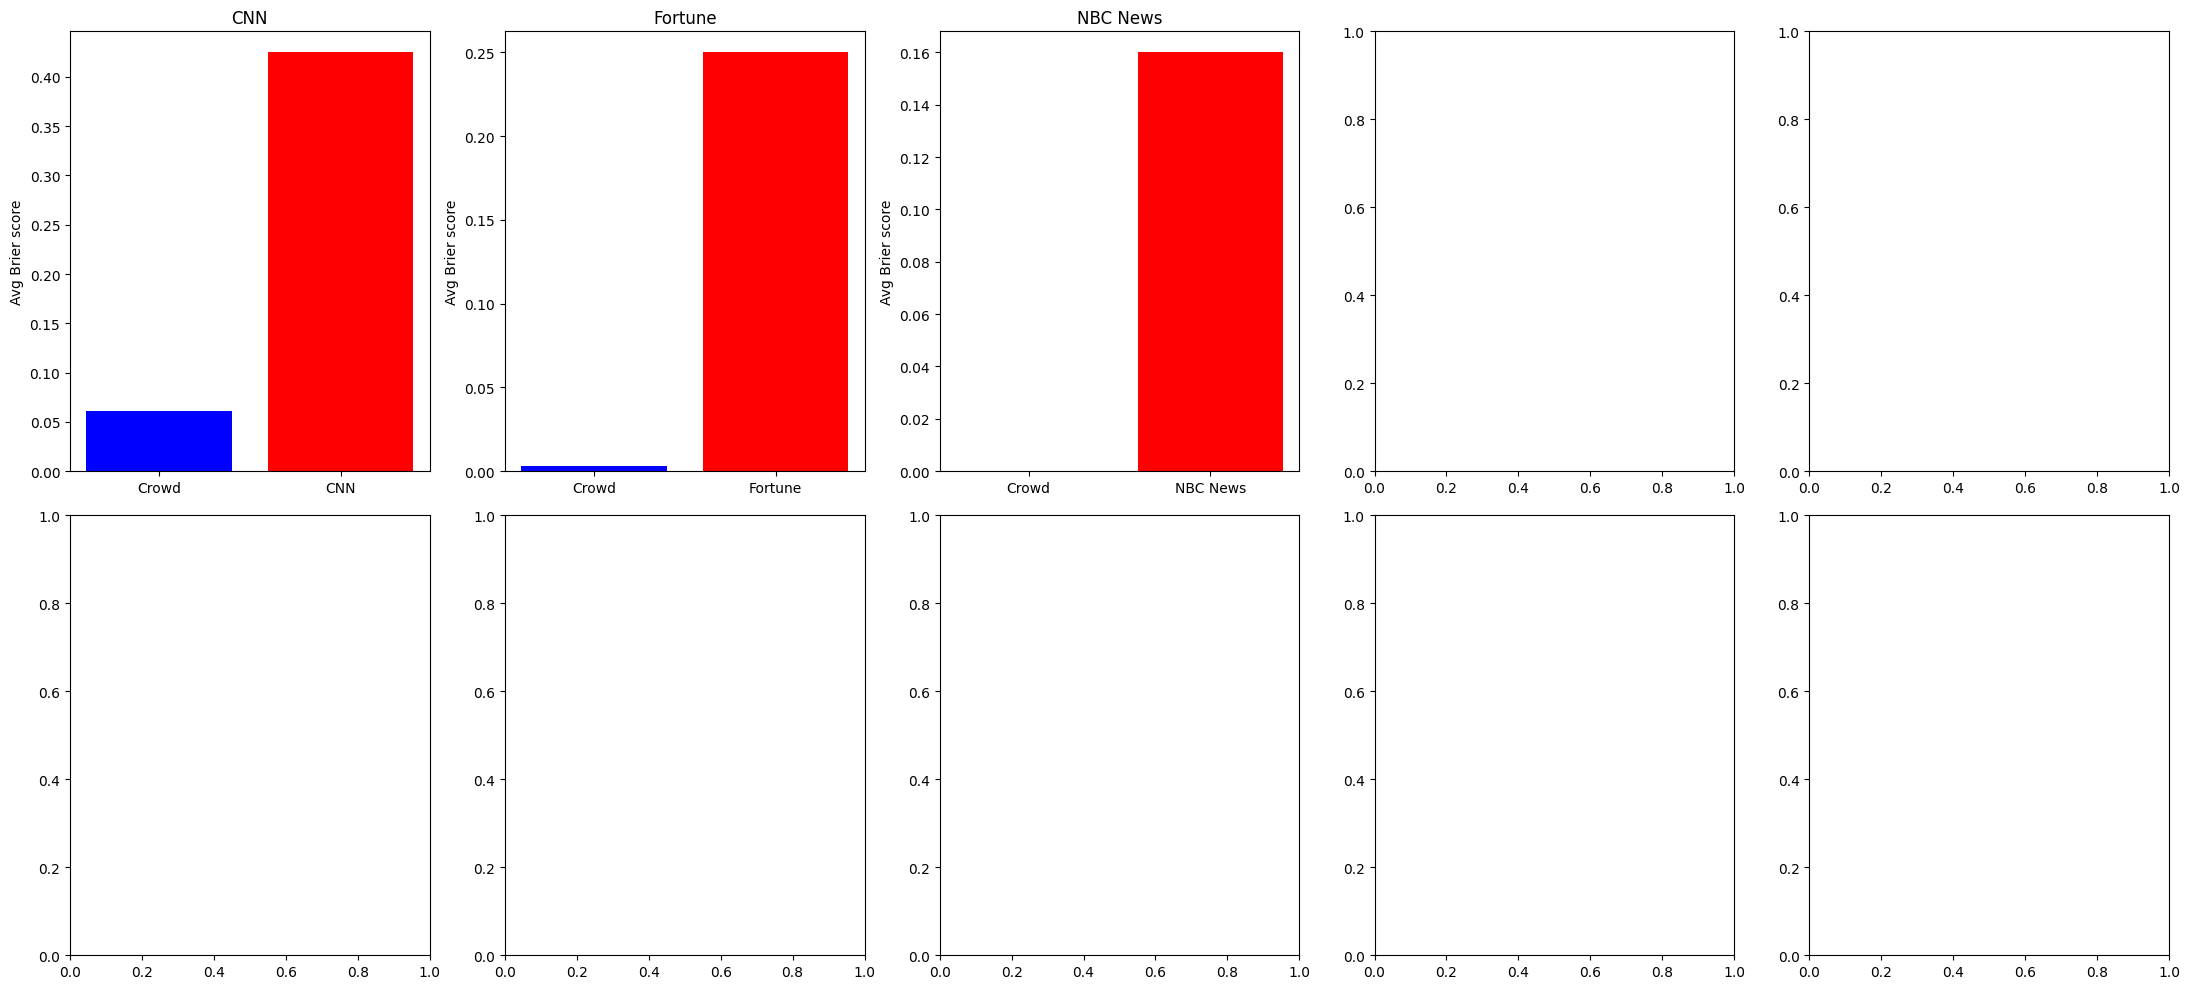

In [25]:
# ============================================================
# CELL 9.5 — Top-10 sources 
# ============================================================

import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime, timedelta

predictions_data = load_json(PREDICTIONS_FILE)

CUTOFF_DAYS = 7

# ============================================================
# 1) SOURCE -> QUESTIONS
# ============================================================

source_question_map = defaultdict(set)

for entry in predictions_data:
    q = entry["question"]

    for _, data in entry["retrieval_date_predictions"].items():
        for source, pred_data in data.get("source_predictions", {}).items():
            if pred_data.get("prediction") is not None:
                source_question_map[source].add(q)

top_sources = sorted(
    source_question_map.keys(),
    key=lambda s: len(source_question_map[s]),
    reverse=True
)[:10]

top_sources_set = set(top_sources)

print("\nTop 10 sources:")
for i, s in enumerate(top_sources, 1):
    print(f"{i:>2}. {s} ({len(source_question_map[s])} questions)")

# ============================================================
# 2) BUILD TABLE
# ============================================================

rows = []

for entry in predictions_data:

    q = entry["question"]
    resolution = float(entry["resolution"])

    q_original = next(qx for qx in all_questions if qx["question"] == q)

    community_predictions = json.loads(q_original["community_predictions"])

    eval_date = (
        datetime.strptime(q_original["date_resolve_at"], "%Y-%m-%d")
        - timedelta(days=CUTOFF_DAYS)
    ).strftime("%Y-%m-%d")

    crowd_pred = get_crowd_prediction_at_date(
        eval_date,
        community_predictions
    )

    crowd_brier = (
        brier_score(crowd_pred, resolution)
        if crowd_pred is not None else None
    )

    per_source = {}
    has_top = False

    for _, data in entry["retrieval_date_predictions"].items():
        for source, pred_data in data.get("source_predictions", {}).items():

            if source not in top_sources_set:
                continue

            pred = pred_data.get("prediction")
            if pred is None:
                continue

            per_source[source] = brier_score(pred, resolution)
            has_top = True

    if not has_top:
        continue

    row = {"question": q, "crowd": crowd_brier}

    for s in top_sources:
        row[s] = per_source.get(s, None)

    rows.append(row)

df = pd.DataFrame(rows)
df = df[["question", "crowd"] + top_sources]

print("\n" + "=" * 120)
print("TOP 10 SOURCES — FILTERED TABLE")
print("=" * 120)
print(df.to_string(index=False))

# ============================================================
# 3) PLOTS (COLORED AVERAGES)
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, src in enumerate(top_sources):

    ax = axes[i]

    crowd_vals = []
    source_vals = []

    for _, row in df.iterrows():
        if pd.notna(row.get(src)) and pd.notna(row.get("crowd")):
            crowd_vals.append(row["crowd"])
            source_vals.append(row[src])

    if len(source_vals) == 0:
        ax.set_title(f"{src}\n(no data)")
        ax.axis("off")
        continue

    crowd_avg = sum(crowd_vals) / len(crowd_vals)
    source_avg = sum(source_vals) / len(source_vals)

    # ---- color logic ----
    if source_avg < crowd_avg:
        src_color = "green"
    elif source_avg > crowd_avg:
        src_color = "red"
    else:
        src_color = "yellow"

    ax.bar(
        ["Crowd", src],
        [crowd_avg, source_avg],
        color=["blue", src_color]
    )

    ax.set_title(src)
    ax.set_ylabel("Avg Brier score")

plt.tight_layout()
plt.show()


SOURCE-LEVEL PERFORMANCE
                                  source   num_questions    num_articles    avg_brier
                                NBC News               1               1       0.1600
                                 Fortune               1               1       0.2500
                                     CNN               2               4       0.4250


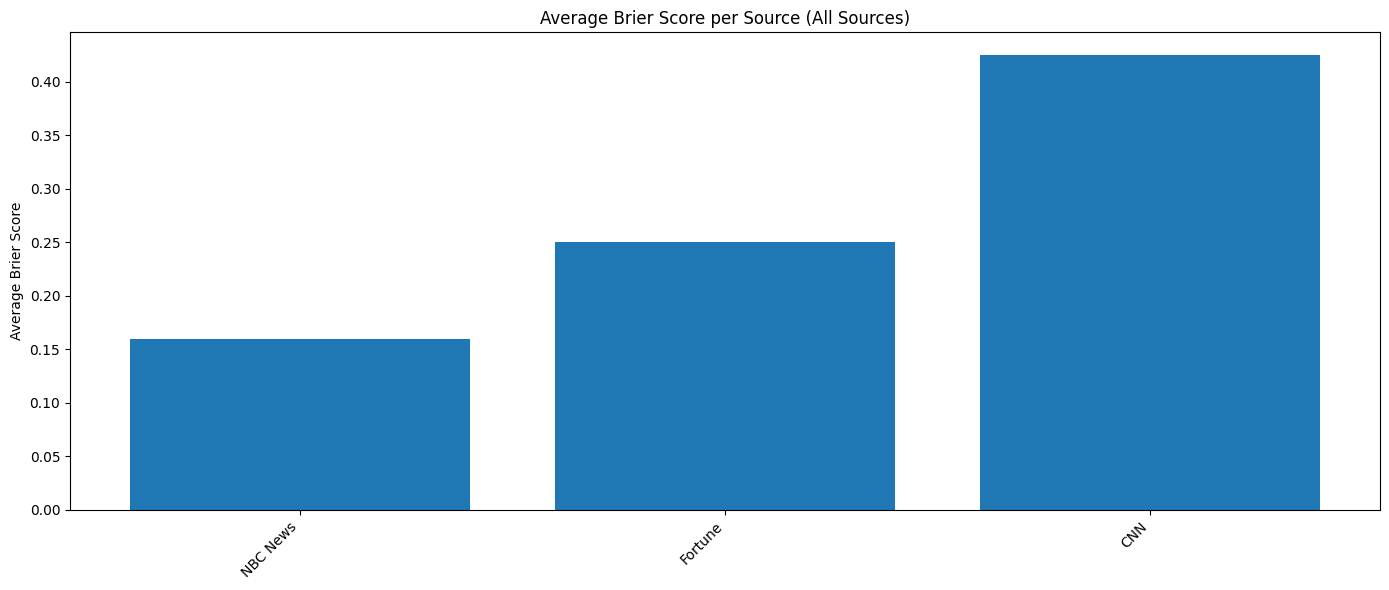


FILTERED SOURCES (>1 article AND >1 question)
                                                                source   num_questions    num_articles    avg_brier
                                                                   CNN               2               4       0.4250


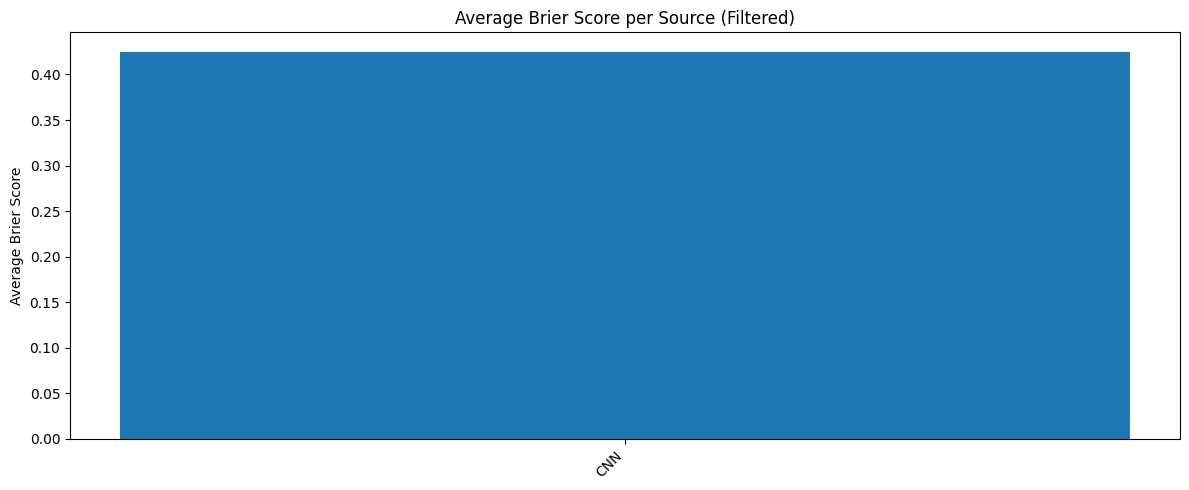

In [26]:
# ============================================================
# CELL 10 — Source-level performance overview
# ============================================================

import json
import warnings
import logging
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# ============================================================
# WARNING / FONT SUPPRESSION
# ============================================================

warnings.filterwarnings("ignore", category=UserWarning)

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ============================================================
# LOAD DATA
# ============================================================

predictions_data = load_json(PREDICTIONS_FILE)
summaries_data   = load_json(SUMMARIES_FILE)

summary_lookup = {
    entry["question"]: entry
    for entry in summaries_data
}

# ============================================================
# AGGREGATE SOURCE STATS
# ============================================================

source_stats = defaultdict(lambda: {
    "questions": set(),
    "article_count": 0,
    "brier_scores": []
})

for pred_entry in predictions_data:

    question   = pred_entry["question"]
    resolution = float(pred_entry["resolution"])

    sum_entry = summary_lookup.get(question)

    if not sum_entry:
        continue

    retrieval_preds = pred_entry.get("retrieval_date_predictions", {})
    retrieval_sums  = sum_entry.get("retrieval_date_summaries", {})

    for retrieval_date, pred_data in retrieval_preds.items():

        source_predictions = pred_data.get("source_predictions", {})

        date_sum_data = retrieval_sums.get(retrieval_date, {})
        summarised_articles = date_sum_data.get("summarised_articles", [])

        # count articles per source
        source_article_counts = defaultdict(int)

        for art in summarised_articles:
            src = art.get("source")

            if src and art.get("summary"):
                source_article_counts[src] += 1

        # process predictions
        for source, src_pred_data in source_predictions.items():

            prediction = src_pred_data.get("prediction")

            if prediction is None:
                continue

            bs = brier_score(prediction, resolution)

            source_stats[source]["questions"].add(question)
            source_stats[source]["article_count"] += source_article_counts.get(source, 0)
            source_stats[source]["brier_scores"].append(bs)

# ============================================================
# BUILD DATAFRAME
# ============================================================

rows = []

for source, stats in source_stats.items():

    if not stats["brier_scores"]:
        continue

    rows.append({
        "source": source,
        "num_questions": len(stats["questions"]),
        "num_articles": stats["article_count"],
        "avg_brier": sum(stats["brier_scores"]) / len(stats["brier_scores"]),
    })

df = pd.DataFrame(rows)

# ============================================================
# EMPTY CASE
# ============================================================

if df.empty:

    print("No source-level predictions found.")

else:

    # sort by best avg brier
    df = df.sort_values("avg_brier")

    # ========================================================
    # PRINT TABLE
    # ========================================================

    print("\n" + "=" * 100)
    print("SOURCE-LEVEL PERFORMANCE")
    print("=" * 100)

    print(
        df.to_string(
            index=False,
            col_space={
                "source": 40,
                "num_questions": 15,
                "num_articles": 15,
                "avg_brier": 12,
            },
            formatters={
                "avg_brier": lambda x: f"{x:.4f}"
            }
        )
    )

    # ========================================================
    # SAFE ASCII LABELS
    # ========================================================

    def safe_ascii(text):
        return text.encode("ascii", errors="ignore").decode("ascii") or "UNKNOWN"

    # ========================================================
    # PLOT 1 — ALL SOURCES
    # ========================================================

    plt.figure(figsize=(14, 6))

    plt.bar(
        [safe_ascii(s) for s in df["source"]],
        df["avg_brier"]
    )

    plt.xticks(rotation=45, ha="right")

    plt.ylabel("Average Brier Score")
    plt.title("Average Brier Score per Source (All Sources)")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # FILTERED DATAFRAME
    # ========================================================

    filtered_df = df[
        (df["num_articles"] > 1) &
        (df["num_questions"] > 1)
    ].copy()

    # ========================================================
    # PLOT 2 — FILTERED SOURCES
    # ========================================================

    if filtered_df.empty:

        print("\nNo sources satisfy the filtering criteria.")

    else:

        filtered_df = filtered_df.sort_values("avg_brier")

        print("\n" + "=" * 100)
        print("FILTERED SOURCES (>1 article AND >1 question)")
        print("=" * 100)

        print(
            filtered_df.to_string(
                index=False,
                col_space={
                    "source": 70,
                    "num_questions": 15,
                    "num_articles": 15,
                    "avg_brier": 12,
                },
                formatters={
                    "avg_brier": lambda x: f"{x:.4f}"
                }
            )
        )

        plt.figure(figsize=(12, 5))

        plt.bar(
            [safe_ascii(s) for s in filtered_df["source"]],
            filtered_df["avg_brier"]
        )

        plt.xticks(rotation=45, ha="right")

        plt.ylabel("Average Brier Score")
        plt.title("Average Brier Score per Source (Filtered)")

        plt.tight_layout()
        plt.show()